In [1]:
import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [2]:
df = pd.read_csv("../data/nyc311.csv")

print(df.head())
print(df.columns)

C:\Users\Dell\AppData\Local\Temp\ipykernel_2024\4065248222.py:1: DtypeWarning: Columns (0: Ferry Direction, 1: Ferry Terminal Name) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/nyc311.csv")


   Unique Key            Created Date             Closed Date Agency  \
0    32310363  12/31/2015 11:59:45 PM  01/01/2016 12:55:15 AM   NYPD   
1    32309934  12/31/2015 11:59:44 PM  01/01/2016 01:26:57 AM   NYPD   
2    32309159  12/31/2015 11:59:29 PM  01/01/2016 04:51:03 AM   NYPD   
3    32305098  12/31/2015 11:57:46 PM  01/01/2016 07:43:13 AM   NYPD   
4    32306529  12/31/2015 11:56:58 PM  01/01/2016 03:24:42 AM   NYPD   

                       Agency Name           Complaint Type  \
0  New York City Police Department  Noise - Street/Sidewalk   
1  New York City Police Department         Blocked Driveway   
2  New York City Police Department         Blocked Driveway   
3  New York City Police Department          Illegal Parking   
4  New York City Police Department          Illegal Parking   

                     Descriptor    Location Type  Incident Zip  \
0              Loud Music/Party  Street/Sidewalk       10034.0   
1                     No Access  Street/Sidewalk       1

In [3]:
df = df[['Complaint Type', 'Descriptor']]

df = df.dropna()

df['text'] = df['Complaint Type'] .astype(str) + " " + df['Descriptor'].astype(str)

print(df.head())

            Complaint Type                    Descriptor  \
0  Noise - Street/Sidewalk              Loud Music/Party   
1         Blocked Driveway                     No Access   
2         Blocked Driveway                     No Access   
3          Illegal Parking  Commercial Overnight Parking   
4          Illegal Parking              Blocked Sidewalk   

                                           text  
0      Noise - Street/Sidewalk Loud Music/Party  
1                    Blocked Driveway No Access  
2                    Blocked Driveway No Access  
3  Illegal Parking Commercial Overnight Parking  
4              Illegal Parking Blocked Sidewalk  


In [4]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text

df["clean_text"] = df["text"].apply(clean_text)

print(df[["text", "clean_text"]].head())

                                           text  \
0      Noise - Street/Sidewalk Loud Music/Party   
1                    Blocked Driveway No Access   
2                    Blocked Driveway No Access   
3  Illegal Parking Commercial Overnight Parking   
4              Illegal Parking Blocked Sidewalk   

                                     clean_text  
0         noise  streetsidewalk loud musicparty  
1                    blocked driveway no access  
2                    blocked driveway no access  
3  illegal parking commercial overnight parking  
4              illegal parking blocked sidewalk  


In [5]:
def get_sentiment(text):

    text = text.lower()

    if "noise" in text or "blocked" in text:
        return "Negative"
    elif "illegal" in text or "accident" in text:
        return "Critical"
    elif "ok" in text:
        return "Neutral"
    else:
        return "Positive"


df["sentiment"] = df["clean_text"].apply(get_sentiment)

print(df["sentiment"].value_counts())

sentiment
Negative    255062
Critical     58830
Positive     44165
Name: count, dtype: int64


In [6]:
stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

def clean_text(text):

    text = text.lower()

    text = re.sub(r"[^a-zA-Z\s]", "", text)

    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

df['clean_text'] = df['text'].apply(clean_text)

In [7]:
X = df['clean_text']

y = df['sentiment']

In [19]:
priority_scores = {
    "Positive": 1,
    "Neutral": 2,
    "Negative": 3,
    "Critical": 5
}

df["priority_score"] = df["sentiment"].map(priority_scores)

print(df[["sentiment", "priority_score"]].head())

  sentiment  priority_score
0  Negative               3
1  Negative               3
2  Negative               3
3  Critical               5
4  Negative               3


In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = vectorizer.fit_transform(X_train)

X_test_tfidf = vectorizer.transform(X_test)

print(X_train_tfidf.shape)

(286445, 90)


In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [25]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=200)

model.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [11]:
y_pred = model.predict(X_test_tfidf)

print(y_pred[:10])

['Negative' 'Negative' 'Negative' 'Negative' 'Positive' 'Critical'
 'Critical' 'Negative' 'Negative' 'Negative']


In [12]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [13]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Critical       1.00      1.00      1.00     11673
    Negative       1.00      1.00      1.00     51148
    Positive       1.00      1.00      1.00      8791

    accuracy                           1.00     71612
   macro avg       1.00      1.00      1.00     71612
weighted avg       1.00      1.00      1.00     71612



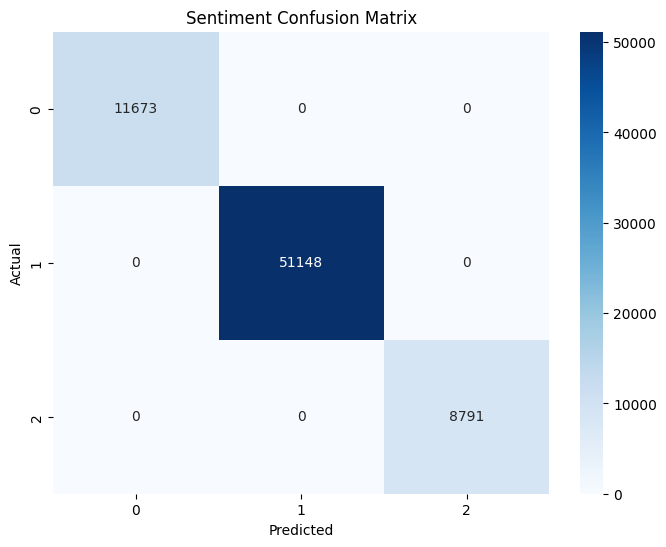

In [14]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Sentiment Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [15]:
priority_scores = {
    "Positive": 1,
    "Neutral": 2,
    "Negative": 3,
    "Critical": 5
}

df['priority_score'] = df['sentiment'].map(priority_scores)

print(df[['text', 'sentiment', 'priority_score']].head())

                                           text sentiment  priority_score
0      Noise - Street/Sidewalk Loud Music/Party  Negative               3
1                    Blocked Driveway No Access  Negative               3
2                    Blocked Driveway No Access  Negative               3
3  Illegal Parking Commercial Overnight Parking  Critical               5
4              Illegal Parking Blocked Sidewalk  Negative               3


In [16]:
sample = ["Flood water entering homes urgently"]

sample_clean = [clean_text(text) for text in sample]

sample_vector = vectorizer.transform(sample_clean)

prediction = model.predict(sample_vector)

print("Predicted Sentiment:", prediction[0])

print("Priority Score:", priority_scores[prediction[0]])

Predicted Sentiment: Positive
Priority Score: 1


In [17]:
model = LogisticRegression(max_iter=200)

model.fit(X_train_tfidf, y_train)

print("Model trained successfully")

Model trained successfully


In [18]:
import joblib

joblib.dump(model, "../models/sentiment_model.pkl")

print("Sentiment model saved successfully")

Sentiment model saved successfully
